# Eksplorasi Fungsi Kovariansi (Kernel) dan Mekanisme Sampling Gaussian Process
**Referensi Utama**: Rasmussen, C. E., & Williams, C. K. (2006). *Gaussian Processes for Machine Learning*. MIT Press.  
**Dokumen Pendukung**: Dokumen Kredit Bimbingan Tugas Akhir #3  

Notebook ini berisi implementasi komputasi numerik, analisis sifat matematis, dan visualisasi grafis untuk dua topik fundamental dari buku teks Rasmussen & Williams (2006):
1. **Eksplorasi Fungsi Kovariansi (Kernel)**: Karakteristik sifat stasioner/non-stasioner, katalog kernel baku (Squared Exponential, Matérn class, Rational Quadratic, dan Linear Dot Product), serta efek fisis dan geometris variasi hyperparameter.
2. **Mekanisme Sampling Gaussian Process**: Formulasi analitik multivariat normal, teorema transformasi linear, faktorisasi Dekomposisi Cholesky ($K = L L^T$), analisis peran stabilisasi *jitter*, dan perbandingan sampling fungsi pada kondisi *Prior* vs *Posterior*.

In [1]:
# 1. Konfigurasi Lingkungan Komputasi dan Gaya Visual
import os
import numpy as np
import matplotlib.pyplot as plt

# Konfigurasi gaya visual publikasi akademik
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8.5,
    'figure.titlesize': 13,
    'lines.linewidth': 1.6,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'mathtext.fontset': 'cm',
    'figure.autolayout': True
})

# Direktori penyimpanan luaran gambar
OUTPUT_DIR = os.path.join(os.path.abspath('.'), 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Random seed untuk reproduktibilitas eksperimen
np.random.seed(42)

print(f"Lingkungan komputasi siap. Direktori luaran gambar: {OUTPUT_DIR}")


## Bagian 1: Definisi dan Formulasi Matematika Fungsi Kovariansi (Kernel)

Fungsi kovariansi $k(\mathbf{x}, \mathbf{x}')$ memetakan pasangan titik input $(\mathbf{x}, \mathbf{x}')$ menjadi ukuran kemiripan atau keterkaitan kovariansi antara $f(\mathbf{x})$ dan $f(\mathbf{x}')$.

Berdasarkan **Rasmussen & Williams (2006, Bab 4)**, fungsi kovariansi standar yang dievaluasi meliputi:
- **Squared Exponential (SE / RBF)**: $$k_{\text{SE}}(r) = \sigma_f^2 \exp\left(-\frac{r^2}{2l^2}\right)$$
- **Exponential (Matérn $\nu=1/2$)**: $$k_{\text{Exp}}(r) = \sigma_f^2 \exp\left(-\frac{r}{l}\right)$$
- **Matérn $\nu=3/2$**: $$k_{\text{M32}}(r) = \sigma_f^2 \left(1 + \frac{\sqrt{3}r}{l}\right) \exp\left(-\frac{\sqrt{3}r}{l}\right)$$
- **Matérn $\nu=5/2$**: $$k_{\text{M52}}(r) = \sigma_f^2 \left(1 + \frac{\sqrt{5}r}{l} + \frac{5r^2}{3l^2}\right) \exp\left(-\frac{\sqrt{5}r}{l}\right)$$
- **Rational Quadratic (RQ)**: $$k_{\text{RQ}}(r) = \sigma_f^2 \left(1 + \frac{r^2}{2\alpha l^2}\right)^{-\alpha}$$
- **Linear / Dot Product**: $$k_{\text{Lin}}(\mathbf{x},\mathbf{x}') = \sigma_b^2 + \sigma_v^2(\mathbf{x}-c)(\mathbf{x}'-c)$$

In [2]:
# 2. Implementasi Fungsi-Fungsi Kernel Baku Rasmussen & Williams (2006)

def kernel_squared_exponential(x1, x2, l=1.0, sigma_f=1.0):
    """Squared Exponential (SE / RBF / Gaussian) Kernel"""
    r_sq = (np.subtract.outer(x1, x2)) ** 2
    return (sigma_f ** 2) * np.exp(-0.5 * r_sq / (l ** 2))

def kernel_exponential(x1, x2, l=1.0, sigma_f=1.0):
    """Exponential / Matérn nu=1/2 Kernel (Ornstein-Uhlenbeck)"""
    r = np.abs(np.subtract.outer(x1, x2))
    return (sigma_f ** 2) * np.exp(-r / l)

def kernel_matern32(x1, x2, l=1.0, sigma_f=1.0):
    """Matérn nu=3/2 Kernel (Once differentiable)"""
    r = np.abs(np.subtract.outer(x1, x2))
    factor = np.sqrt(3.0) * r / l
    return (sigma_f ** 2) * (1.0 + factor) * np.exp(-factor)

def kernel_matern52(x1, x2, l=1.0, sigma_f=1.0):
    """Matérn nu=5/2 Kernel (Twice differentiable)"""
    r = np.abs(np.subtract.outer(x1, x2))
    factor = np.sqrt(5.0) * r / l
    return (sigma_f ** 2) * (1.0 + factor + (5.0 * (r ** 2)) / (3.0 * (l ** 2))) * np.exp(-factor)

def kernel_rational_quadratic(x1, x2, l=1.0, sigma_f=1.0, alpha=1.0):
    """Rational Quadratic (RQ) Kernel (Scale Mixture)"""
    r_sq = (np.subtract.outer(x1, x2)) ** 2
    return (sigma_f ** 2) * (1.0 + r_sq / (2.0 * alpha * (l ** 2))) ** (-alpha)

def kernel_linear(x1, x2, sigma_b=0.0, sigma_v=1.0, c=0.0):
    """Linear (Dot Product) Kernel (Non-stasioner)"""
    return (sigma_b ** 2) + (sigma_v ** 2) * np.outer(x1 - c, x2 - c)

def sample_gp_prior(x_grid, kernel_func, n_samples=4, jitter=1e-6, **kwargs):
    """Fungsi sampling prior GP menggunakan Dekomposisi Cholesky"""
    K = kernel_func(x_grid, x_grid, **kwargs)
    K_stable = K + jitter * np.eye(len(x_grid))
    L = np.linalg.cholesky(K_stable)
    u = np.random.randn(len(x_grid), n_samples)
    f_samples = L @ u
    return f_samples, K, L

print("Seluruh fungsi kernel dan sampling helper berhasil didefinisikan.")


## Eksplorasi 1: Karakteristik Nilai Kovariansi dan Realisasi Sampel Fungsi Prior (Rasmussen & Williams, 2006)

Berikut adalah visualisasi komparatif antara fungsi kovariansi $k(r)$ terhadap jarak Euclidean $r = \|\mathbf{x} - \mathbf{x}^\prime\|$ berdampingan dengan realisasi sampel fungsi prior $f(x)$ yang dibangkitkan dari vektor noise baku $\mathbf{u}$ yang identik.


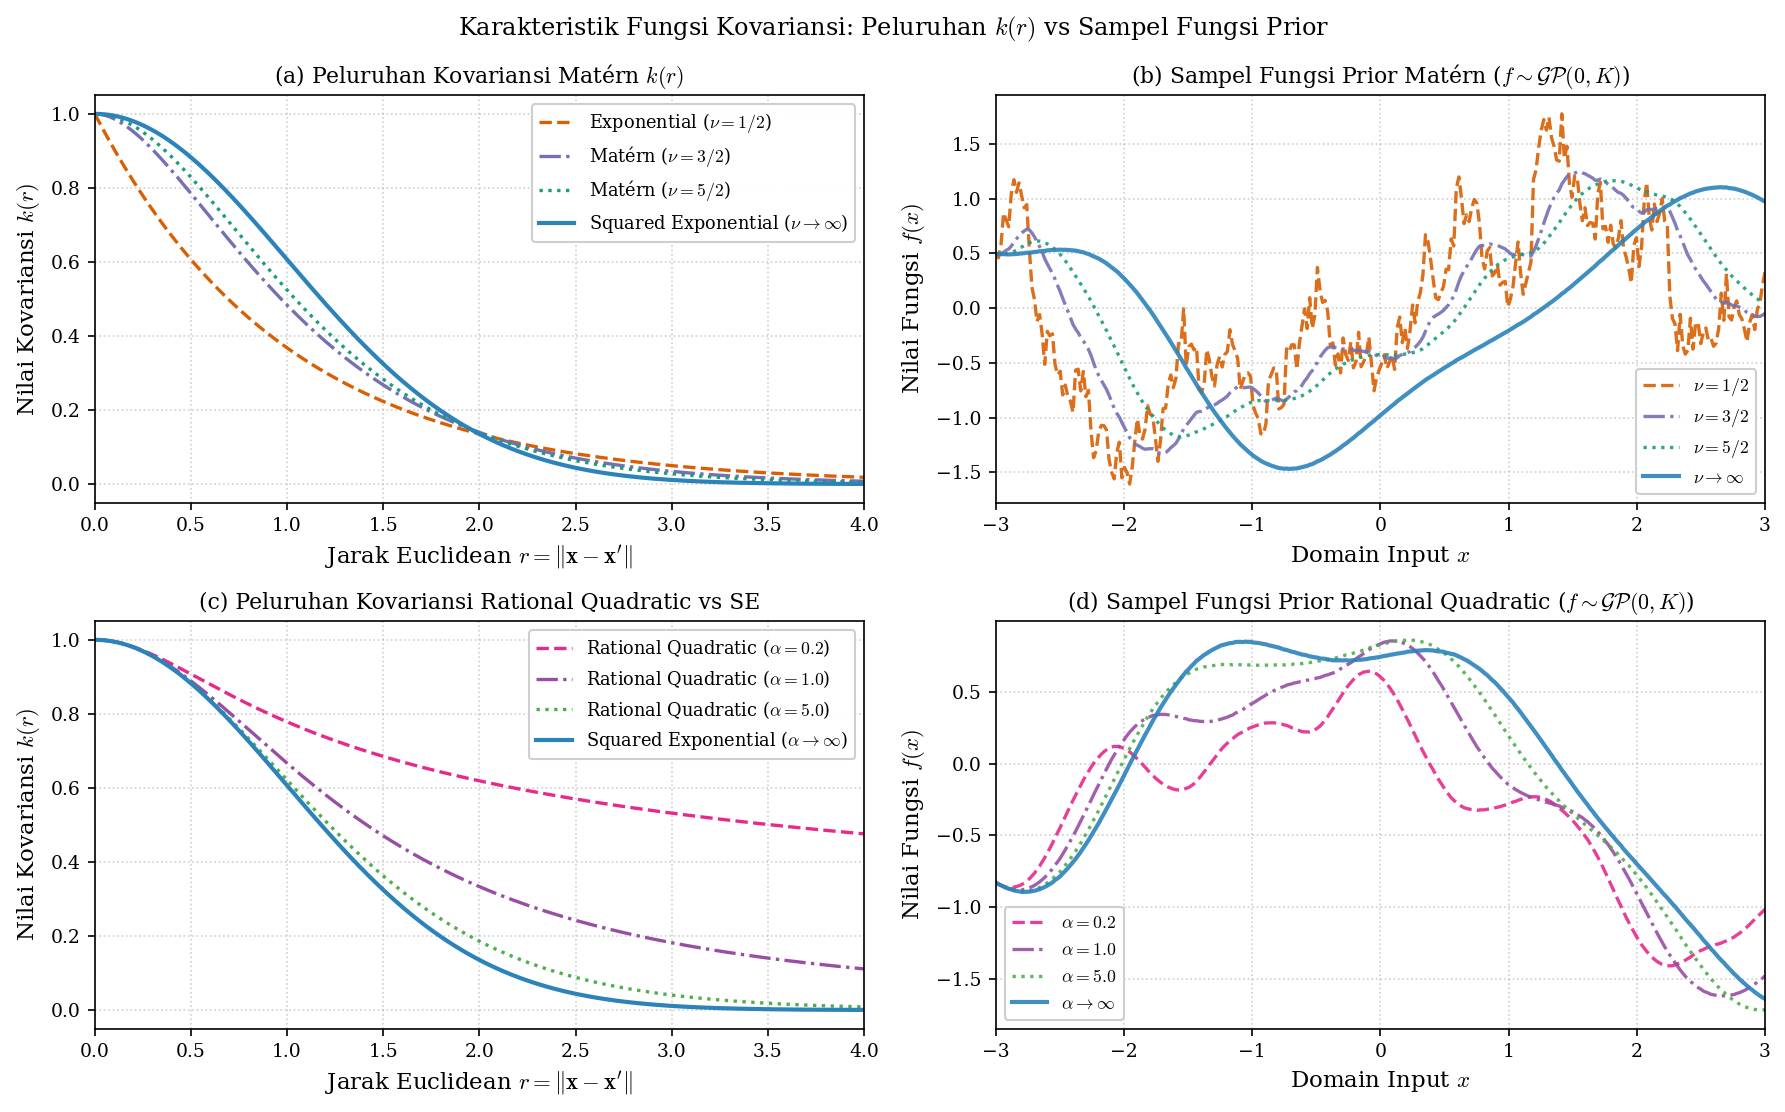

In [3]:
# Visualisasi Karakteristik Kovariansi: Peluruhan k(r) vs Sampel Prior f(x) (Gambar 1)
r = np.linspace(0, 4.0, 500)
x_grid = np.linspace(-3.0, 3.0, 300)

# Vektor noise tetap (Rasmussen style: noise sama memperjelas murni dampak kernel)
np.random.seed(42)
u_fixed_1 = np.random.randn(len(x_grid))
u_fixed_2 = np.random.randn(len(x_grid))

# 1. Kovariansi Matern
k_m12 = kernel_exponential(r, np.array([0.0]), l=1.0, sigma_f=1.0).flatten()
k_m32 = kernel_matern32(r, np.array([0.0]), l=1.0, sigma_f=1.0).flatten()
k_m52 = kernel_matern52(r, np.array([0.0]), l=1.0, sigma_f=1.0).flatten()
k_se  = kernel_squared_exponential(r, np.array([0.0]), l=1.0, sigma_f=1.0).flatten()

# Sampel Matern (u identik)
_, _, L_m12 = sample_gp_prior(x_grid, kernel_exponential, l=1.0, sigma_f=1.0)
f_m12 = L_m12 @ u_fixed_1

_, _, L_m32 = sample_gp_prior(x_grid, kernel_matern32, l=1.0, sigma_f=1.0)
f_m32 = L_m32 @ u_fixed_1

_, _, L_m52 = sample_gp_prior(x_grid, kernel_matern52, l=1.0, sigma_f=1.0)
f_m52 = L_m52 @ u_fixed_1

_, _, L_se = sample_gp_prior(x_grid, kernel_squared_exponential, l=1.0, sigma_f=1.0)
f_se = L_se @ u_fixed_1

# 2. Kovariansi Rational Quadratic
k_rq_02 = kernel_rational_quadratic(r, np.array([0.0]), l=1.0, sigma_f=1.0, alpha=0.2).flatten()
k_rq_10 = kernel_rational_quadratic(r, np.array([0.0]), l=1.0, sigma_f=1.0, alpha=1.0).flatten()
k_rq_50 = kernel_rational_quadratic(r, np.array([0.0]), l=1.0, sigma_f=1.0, alpha=5.0).flatten()

# Sampel Rational Quadratic (u identik)
_, _, L_rq_02 = sample_gp_prior(x_grid, kernel_rational_quadratic, l=1.0, sigma_f=1.0, alpha=0.2)
f_rq_02 = L_rq_02 @ u_fixed_2

_, _, L_rq_10 = sample_gp_prior(x_grid, kernel_rational_quadratic, l=1.0, sigma_f=1.0, alpha=1.0)
f_rq_10 = L_rq_10 @ u_fixed_2

_, _, L_rq_50 = sample_gp_prior(x_grid, kernel_rational_quadratic, l=1.0, sigma_f=1.0, alpha=5.0)
f_rq_50 = L_rq_50 @ u_fixed_2

f_rq_se = L_se @ u_fixed_2

# Plotting Gambar 1
fig, axs = plt.subplots(2, 2, figsize=(12, 7.5))

# Panel (a): Peluruhan Kovariansi Matern
ax1 = axs[0, 0]
ax1.plot(r, k_m12, label=r'Exponential ($\nu=1/2$)', color='#d95f02', linestyle='--')
ax1.plot(r, k_m32, label=r'Matérn ($\nu=3/2$)', color='#7570b3', linestyle='-.')
ax1.plot(r, k_m52, label=r'Matérn ($\nu=5/2$)', color='#1b9e77', linestyle=':')
ax1.plot(r, k_se, label=r'Squared Exponential ($\nu \to \infty$)', color='#2b83ba', linewidth=2.0)
ax1.set_title(r'(a) Peluruhan Kovariansi Matérn $k(r)$', fontsize=10.5)
ax1.set_xlabel(r'Jarak Euclidean $r = \|\mathbf{x} - \mathbf{x}^\prime\|$')
ax1.set_ylabel(r'Nilai Kovariansi $k(r)$')
ax1.set_xlim([0, 4.0])
ax1.set_ylim([-0.05, 1.05])
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', framealpha=0.95)

# Panel (b): Sampel Matern (Legend di KANAN BAWAH)
ax2 = axs[0, 1]
ax2.plot(x_grid, f_m12, label=r'$\nu=1/2$', color='#d95f02', linestyle='--', alpha=0.9)
ax2.plot(x_grid, f_m32, label=r'$\nu=3/2$', color='#7570b3', linestyle='-.', alpha=0.9)
ax2.plot(x_grid, f_m52, label=r'$\nu=5/2$', color='#1b9e77', linestyle=':', alpha=0.9)
ax2.plot(x_grid, f_se, label=r'$\nu \to \infty$', color='#2b83ba', linewidth=2.0, alpha=0.9)
ax2.set_title(r'(b) Sampel Fungsi Prior Matérn ($f \sim \mathcal{GP}(0, K)$)', fontsize=10.5)
ax2.set_xlabel(r'Domain Input $x$')
ax2.set_ylabel(r'Nilai Fungsi $f(x)$')
ax2.set_xlim([-3.0, 3.0])
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right', framealpha=0.95)

# Panel (c): Peluruhan Kovariansi RQ vs SE
ax3 = axs[1, 0]
ax3.plot(r, k_rq_02, label=r'Rational Quadratic ($\alpha=0.2$)', color='#e7298a', linestyle='--')
ax3.plot(r, k_rq_10, label=r'Rational Quadratic ($\alpha=1.0$)', color='#984ea3', linestyle='-.')
ax3.plot(r, k_rq_50, label=r'Rational Quadratic ($\alpha=5.0$)', color='#4daf4a', linestyle=':')
ax3.plot(r, k_se, label=r'Squared Exponential ($\alpha \to \infty$)', color='#2b83ba', linewidth=2.0)
ax3.set_title(r'(c) Peluruhan Kovariansi Rational Quadratic vs SE', fontsize=10.5)
ax3.set_xlabel(r'Jarak Euclidean $r = \|\mathbf{x} - \mathbf{x}^\prime\|$')
ax3.set_ylabel(r'Nilai Kovariansi $k(r)$')
ax3.set_xlim([0, 4.0])
ax3.set_ylim([-0.05, 1.05])
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(loc='upper right', framealpha=0.95)

# Panel (d): Sampel RQ
ax4 = axs[1, 1]
ax4.plot(x_grid, f_rq_02, label=r'$\alpha=0.2$', color='#e7298a', linestyle='--', alpha=0.9)
ax4.plot(x_grid, f_rq_10, label=r'$\alpha=1.0$', color='#984ea3', linestyle='-.', alpha=0.9)
ax4.plot(x_grid, f_rq_50, label=r'$\alpha=5.0$', color='#4daf4a', linestyle=':', alpha=0.9)
ax4.plot(x_grid, f_rq_se, label=r'$\alpha \to \infty$', color='#2b83ba', linewidth=2.0, alpha=0.9)
ax4.set_title(r'(d) Sampel Fungsi Prior Rational Quadratic ($f \sim \mathcal{GP}(0, K)$)', fontsize=10.5)
ax4.set_xlabel(r'Domain Input $x$')
ax4.set_ylabel(r'Nilai Fungsi $f(x)$')
ax4.set_xlim([-3.0, 3.0])
ax4.grid(True, linestyle=':', alpha=0.6)
ax4.legend(loc='lower left', framealpha=0.95)

fig.suptitle(r'Karakteristik Fungsi Kovariansi: Peluruhan $k(r)$ vs Sampel Fungsi Prior', fontsize=11.5)
plt.tight_layout()

# Simpan luaran gambar berkualitas tinggi
fig.savefig(os.path.join(OUTPUT_DIR, 'fig1_kernel_profiles.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'fig1_kernel_profiles.png'), bbox_inches='tight')
plt.show()



## Eksplorasi 2: Galeri Realisasi Sampel Fungsi Prior $\mathbf{f} \sim \mathcal{GP}(0, K)

Di bawah ini disajikan galeri kurva sampel fungsi acak yang dibangkitkan dari 6 kelas kernel baku dari buku teks Rasmussen & Williams:
1. **Squared Exponential (SE)**: Kurva sangat mulus.
2. **Exponential / Matérn 1/2**: Kurva kasar bergerigi.
3. **Matérn 3/2**: Kurva dengan kehalusan teratur untuk fenomena fisik realistis.
4. **Matérn 5/2**: Kurva lebih mulus dari Matérn 3/2.
5. **Rational Quadratic (RQ)**: Memodelkan variasi multi-skala.
6. **Linear**: Menghasilkan garis lurus acak dengan corong variansi non-stasioner yang melebar seiring menjauhi titik tumpu $c$.


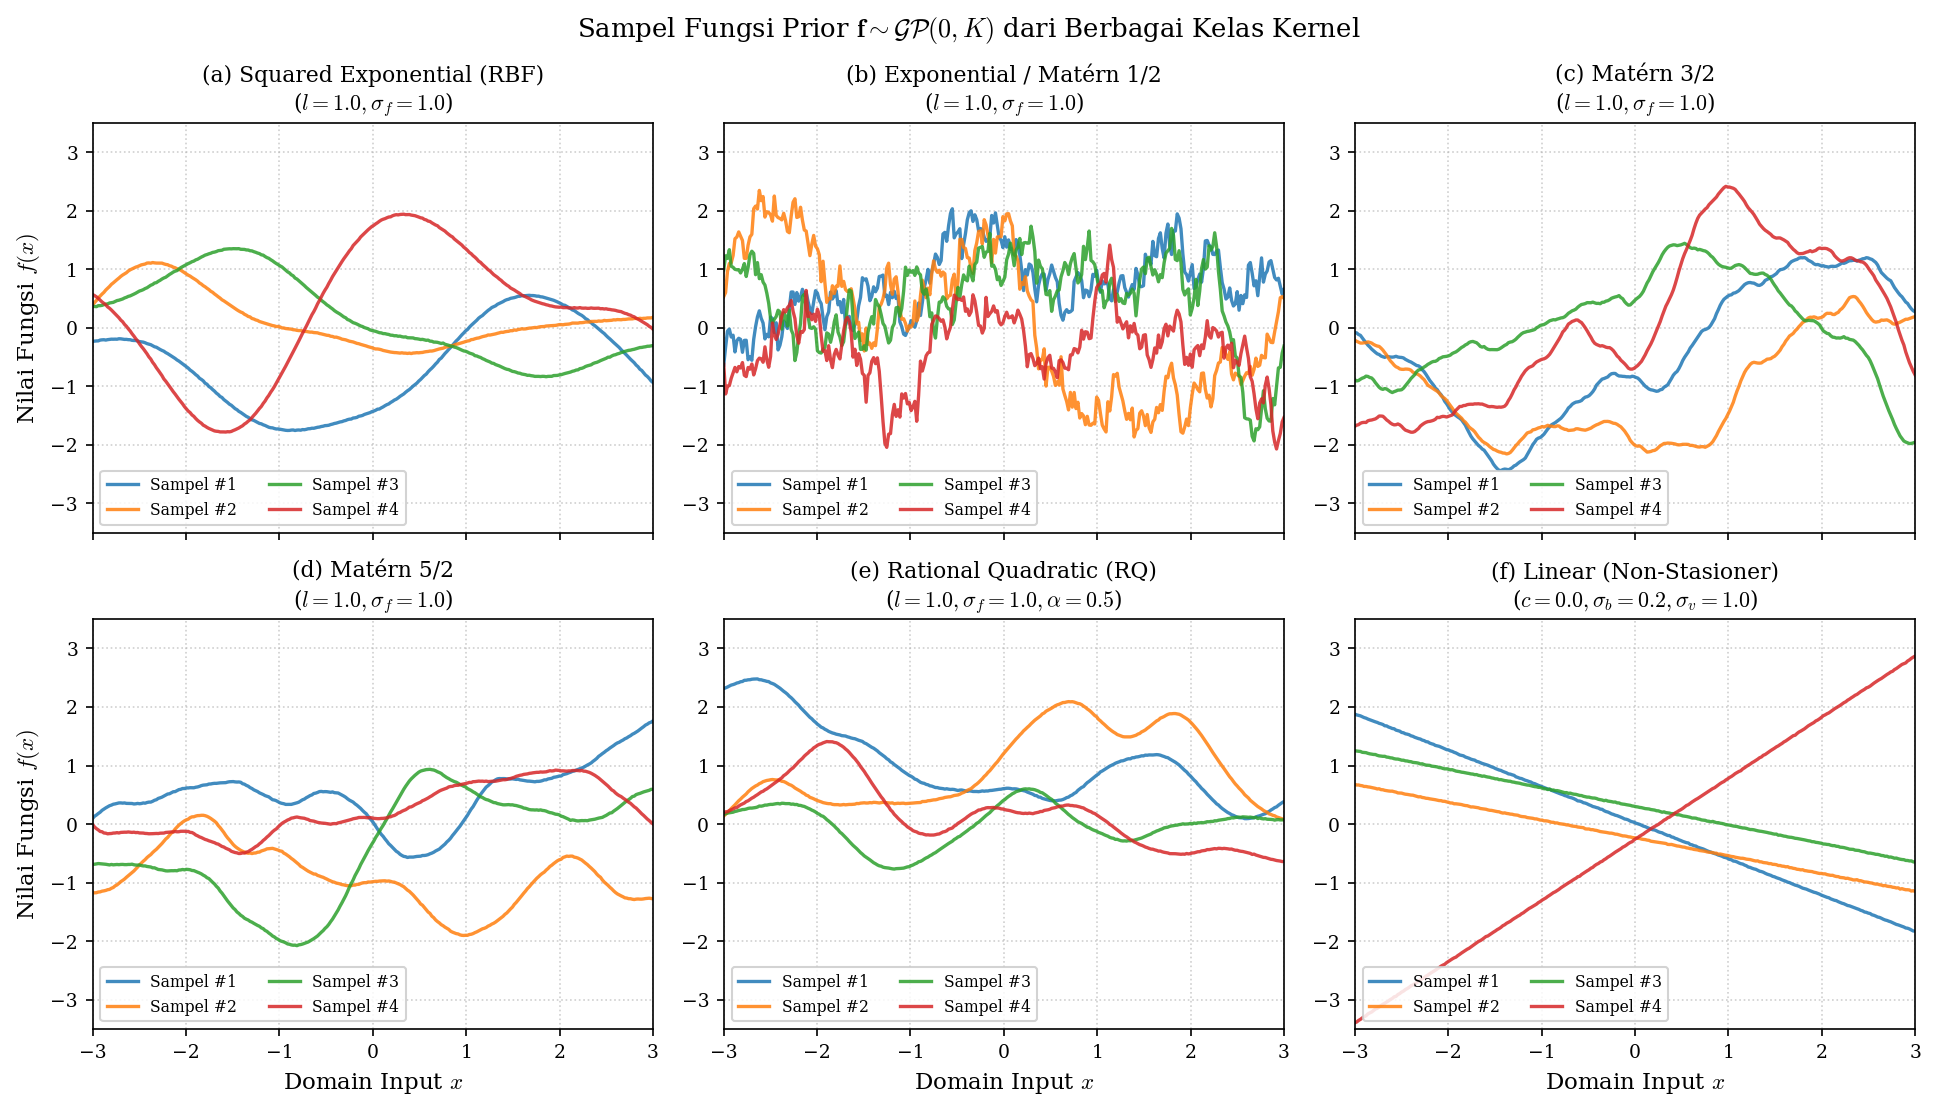

In [4]:
# Visualisasi Sampel Fungsi Prior (Gambar 2)
x_grid = np.linspace(-3.0, 3.0, 300)

kernel_configs = [
    ("(a) Squared Exponential (RBF)\n" + r"($l=1.0, \sigma_f=1.0$)", 
     kernel_squared_exponential, {'l': 1.0, 'sigma_f': 1.0}),
    ("(b) Exponential / Matérn 1/2\n" + r"($l=1.0, \sigma_f=1.0$)", 
     kernel_exponential, {'l': 1.0, 'sigma_f': 1.0}),
    ("(c) Matérn 3/2\n" + r"($l=1.0, \sigma_f=1.0$)", 
     kernel_matern32, {'l': 1.0, 'sigma_f': 1.0}),
    ("(d) Matérn 5/2\n" + r"($l=1.0, \sigma_f=1.0$)", 
     kernel_matern52, {'l': 1.0, 'sigma_f': 1.0}),
    ("(e) Rational Quadratic (RQ)\n" + r"($l=1.0, \sigma_f=1.0, \alpha=0.5$)", 
     kernel_rational_quadratic, {'l': 1.0, 'sigma_f': 1.0, 'alpha': 0.5}),
    ("(f) Linear (Non-Stasioner)\n" + r"($c=0.0, \sigma_b=0.2, \sigma_v=1.0$)", 
     kernel_linear, {'sigma_b': 0.2, 'sigma_v': 1.0, 'c': 0.0})
]

fig, axs = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True)
axs = axs.flatten()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (title, k_func, kwargs) in enumerate(kernel_configs):
    ax = axs[i]
    np.random.seed(150 + i)
    f_samples, _, _ = sample_gp_prior(x_grid, k_func, n_samples=4, jitter=1e-5, **kwargs)
    
    for s in range(4):
        ax.plot(x_grid, f_samples[:, s], color=colors[s], alpha=0.85, label=f'Sampel #{s+1}')
    
    ax.set_title(title, fontsize=10.5, pad=6)
    ax.set_xlim([-3.0, 3.0])
    ax.set_ylim([-3.5, 3.5])
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower left', fontsize=7.5, ncol=2, framealpha=0.85)
    if i >= 3:
        ax.set_xlabel(r'Domain Input $x$')
    if i % 3 == 0:
        ax.set_ylabel(r'Nilai Fungsi $f(x)$')
        
fig.suptitle(r'Sampel Fungsi Prior $\mathbf{f} \sim \mathcal{GP}(0, K)$ dari Berbagai Kelas Kernel', fontsize=12.5)
plt.tight_layout()

# Simpan ke PDF & PNG
fig.savefig(os.path.join(OUTPUT_DIR, 'fig2_sample_paths_kernels.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'fig2_sample_paths_kernels.png'), bbox_inches='tight')
plt.show()



## Eksplorasi 3: Eksperimen Variasi Nilai Hyperparameter terhadap Perilaku Fungsi Prior

Setiap parameter pada fungsi kovariansi mengontrol sifat fisis dan geometris tertentu dari ruang fungsi:
1. **$l$ (Lengthscale)**: Mengatur frekuensi spasial horizontal (kerapatan fluktuasi).
2. **$\sigma_f^2$ (Signal Variance)**: Mengatur skala amplitudo vertikal simpangan fungsi.
3. **$\alpha$ (Scale Mixture)**: Mengatur keragaman skala spasial pada Rational Quadratic.
4. **$c$ (Titik Tumpu Linear)**: Menggeser lokasi titik tumpu variansi minimum.


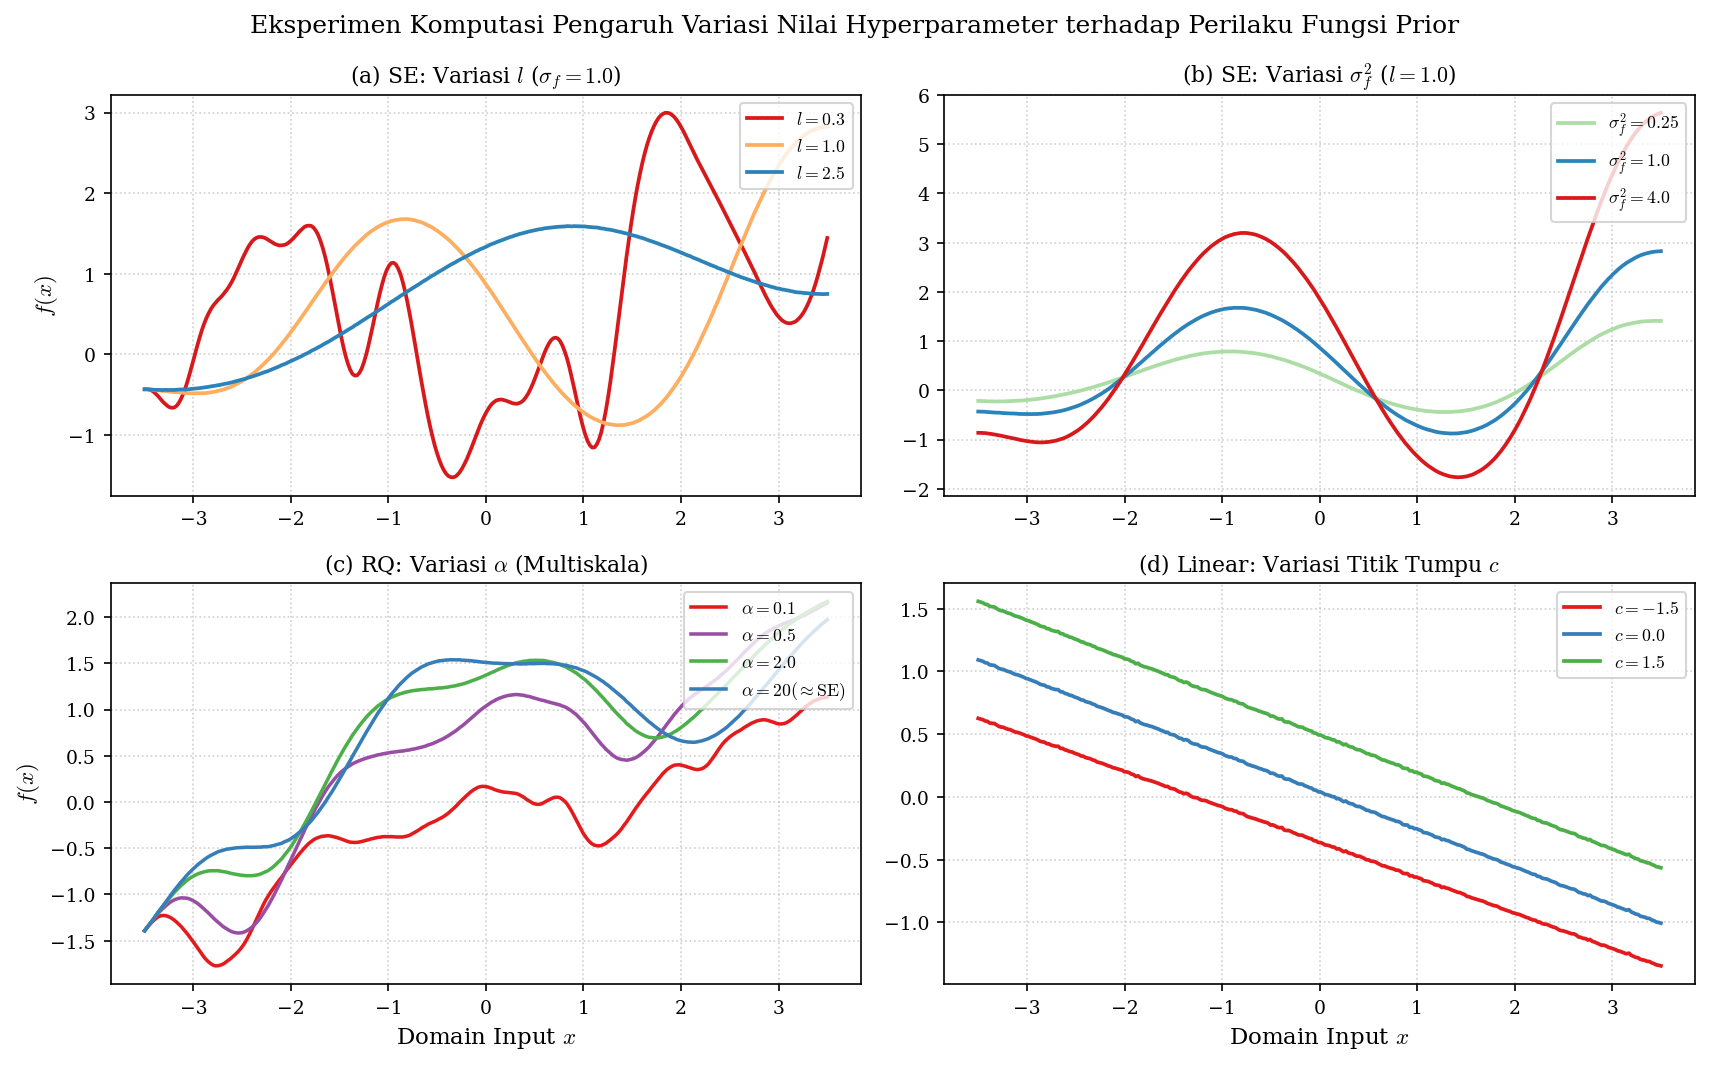

In [5]:
# Visualisasi Pengaruh Hyperparameter (Gambar 3)
x_grid = np.linspace(-3.5, 3.5, 300)

fig, axs = plt.subplots(2, 2, figsize=(11.5, 7.2))
np.random.seed(2026)
u_fixed = np.random.randn(len(x_grid), 3)

# 1. Variasi Lengthscale l pada SE
ax1 = axs[0, 0]
for l_val, col in zip([0.3, 1.0, 2.5], ['#d7191c', '#fdae61', '#2b83ba']):
    K = kernel_squared_exponential(x_grid, x_grid, l=l_val, sigma_f=1.0) + 1e-6 * np.eye(len(x_grid))
    L = np.linalg.cholesky(K)
    f_s = L @ u_fixed[:, 0]
    ax1.plot(x_grid, f_s, label=rf'$l = {l_val}$', color=col, lw=1.8)
ax1.set_title(r'(a) SE: Variasi $l$ ($\sigma_f=1.0$)', fontsize=10.5)
ax1.set_ylabel(r'$f(x)$')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# 2. Variasi Signal Variance sigma_f^2 pada SE
ax2 = axs[0, 1]
for sf_sq, col in zip([0.25, 1.0, 4.0], ['#abdda4', '#2b83ba', '#d7191c']):
    sf = np.sqrt(sf_sq)
    K = kernel_squared_exponential(x_grid, x_grid, l=1.0, sigma_f=sf) + 1e-6 * np.eye(len(x_grid))
    L = np.linalg.cholesky(K)
    f_s = L @ u_fixed[:, 0]
    ax2.plot(x_grid, f_s, label=rf'$\sigma_f^2 = {sf_sq}$', color=col, lw=1.8)
ax2.set_title(r'(b) SE: Variasi $\sigma_f^2$ ($l=1.0$)', fontsize=10.5)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')

# 3. Variasi Scale Mixture alpha pada RQ
ax3 = axs[1, 0]
for a_val, col in zip([0.1, 0.5, 2.0, 20.0], ['#e41a1c', '#984ea3', '#4daf4a', '#377eb8']):
    K = kernel_rational_quadratic(x_grid, x_grid, l=1.0, sigma_f=1.0, alpha=a_val) + 1e-6 * np.eye(len(x_grid))
    L = np.linalg.cholesky(K)
    f_s = L @ u_fixed[:, 1]
    lbl = r'$\alpha = 20 (\approx\mathrm{SE})$' if a_val == 20.0 else rf'$\alpha = {a_val}$'
    ax3.plot(x_grid, f_s, label=lbl, color=col, lw=1.7)
ax3.set_title(r'(c) RQ: Variasi $\alpha$ (Multiskala)', fontsize=10.5)
ax3.set_xlabel(r'Domain Input $x$')
ax3.set_ylabel(r'$f(x)$')
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(loc='upper right')

# 4. Variasi Titik Tumpu c pada Linear Kernel
ax4 = axs[1, 1]
for c_val, col in zip([-1.5, 0.0, 1.5], ['#e41a1c', '#377eb8', '#4daf4a']):
    K = kernel_linear(x_grid, x_grid, sigma_b=0.2, sigma_v=1.0, c=c_val) + 1e-5 * np.eye(len(x_grid))
    L = np.linalg.cholesky(K)
    f_s = L @ u_fixed[:, 2]
    ax4.plot(x_grid, f_s, label=rf'$c = {c_val}$', color=col, lw=1.8)
ax4.set_title(r'(d) Linear: Variasi Titik Tumpu $c$', fontsize=10.5)
ax4.set_xlabel(r'Domain Input $x$')
ax4.grid(True, linestyle=':', alpha=0.6)
ax4.legend(loc='upper right')

fig.suptitle(r'Eksperimen Komputasi Pengaruh Variasi Nilai Hyperparameter terhadap Perilaku Fungsi Prior', fontsize=12.0)

# Simpan ke PDF & PNG
fig.savefig(os.path.join(OUTPUT_DIR, 'fig3_hyperparameter_effects.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'fig3_hyperparameter_effects.png'), bbox_inches='tight')
plt.show()


## Bagian 2: Mencari Sample dari Distribusi Gaussian Process

### **1. Formulasi Masalah & Konsistensi Hingga Dimensi**
Untuk $N_*$ titik uji $X_* = [\mathbf{x}_{*1}, \dots, \mathbf{x}_{*N_*}]^T \in \mathbb{R}^{N_* \times D}$, sifat konsistensi hingga dimensi menyatakan bahwa nilai fungsi berdistribusi Gaussian Multivariat bersama:
$$\mathbf{f}_* \sim \mathcal{N}\left( \mathbf{m}_*, K(X_*, X_*) \right)$$
di mana $\mathbf{m}_* = [m(\mathbf{x}_{*1}), \dots, m(\mathbf{x}_{*N_*})]^T$ dan $K_{ij} = k(\mathbf{x}_{*i}, \mathbf{x}_{*j})$.

---

### **2. Algoritma Sampling GP Berbasis Transformasi Affine Cholesky**
Karena generator acak hanya membangkitkan vektor normal baku $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I_{N_*})$, sampel $\mathbf{f}_*$ diperoleh melalui 4 langkah:
1. **Evaluasi & Regularisasi Kovariansi**: $\tilde{K} = K(X_*, X_*) + \epsilon I_{N_*}$ (dengan $\epsilon \approx 10^{-6}$ untuk kestabilan numerik).
2. **Faktorisasi Cholesky**: Dekomposisi $\tilde{K} = L L^T$, di mana $L$ adalah matriks segitiga bawah unik.
3. **Pembangkitan Noise Baku**: $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I_{N_*})$. Untuk $S$ sampel: $U \in \mathbb{R}^{N_* \times S}$ dengan $U_{ij} \sim \mathcal{N}(0, 1)$.
4. **Transformasi Affine**: $\mathbf{f}_* = \mathbf{m}_* + L \mathbf{u}$ (atau $F = \mathbf{m}_* \mathbf{1}_S^T + L U$ untuk $S$ kurva sekaligus).

---

### **3. Justifikasi Matematis (Teorema Transformasi Affine)**
Berdasarkan teorema bahwa jika $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$ dan $\mathbf{f}_* = L\mathbf{u} + \mathbf{m}_*$, maka:
- **Mean**: $\mathbb{E}[\mathbf{f}_*] = \mathbf{m}_* + L \mathbb{E}[\mathbf{u}] = \mathbf{m}_*$
- **Kovariansi**: $\operatorname{cov}(\mathbf{f}_*) = L \mathbb{E}[\mathbf{u}\mathbf{u}^T] L^T = L I L^T = L L^T = \tilde{K} \approx K$

Terbukti secara eksak bahwa $\mathbf{f}_* \sim \mathcal{N}(\mathbf{m}_*, K)$.

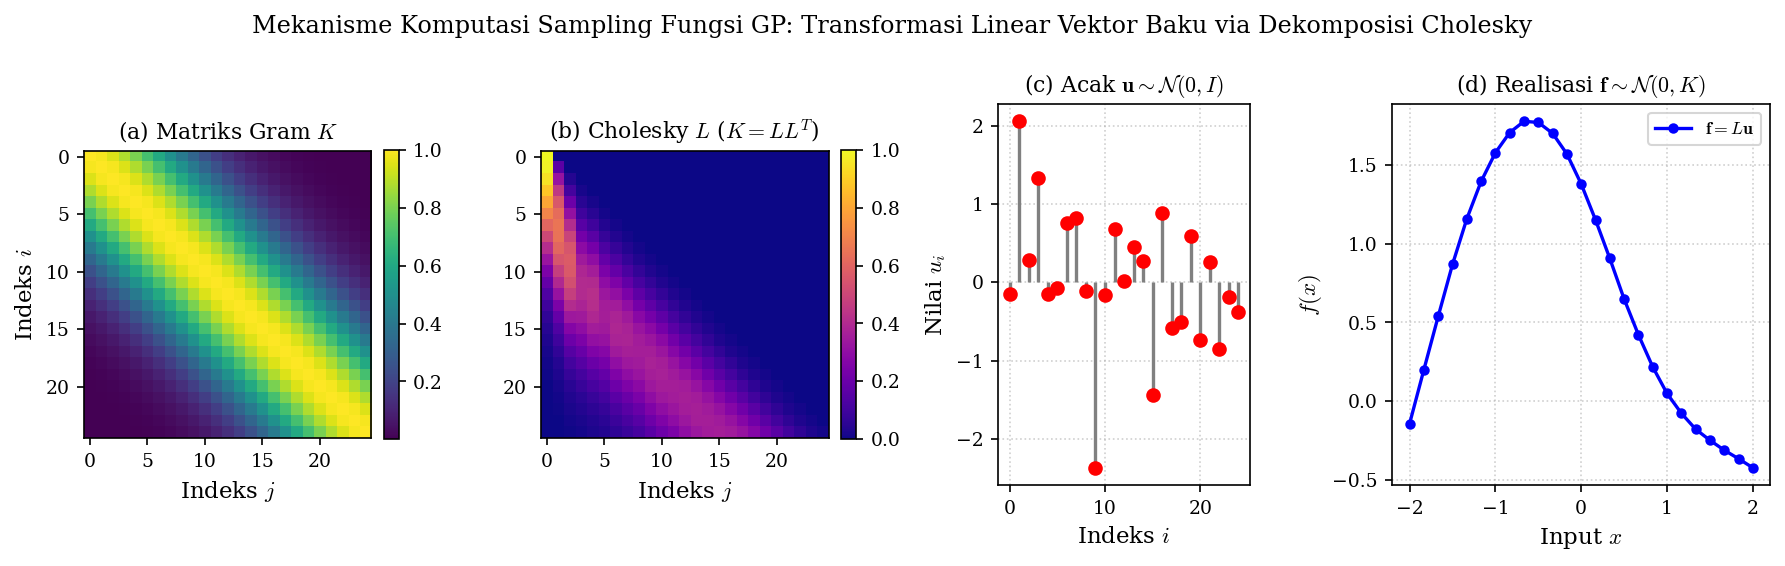

In [6]:
# Visualisasi Alur Sampling Cholesky (Gambar 4)
x_small = np.linspace(-2.0, 2.0, 25)
K = kernel_squared_exponential(x_small, x_small, l=1.0, sigma_f=1.0) + 1e-5 * np.eye(len(x_small))
L = np.linalg.cholesky(K)

np.random.seed(99)
u = np.random.randn(len(x_small), 1)
f = L @ u

fig = plt.figure(figsize=(12, 3.8))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.8, 1.2])

# 1. Heatmap K
ax1 = fig.add_subplot(gs[0])
im1 = ax1.imshow(K, cmap='viridis', origin='upper')
ax1.set_title(r'(a) Matriks Gram $K$', fontsize=10.5)
ax1.set_xlabel('Indeks $j$')
ax1.set_ylabel('Indeks $i$')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 2. Heatmap L (Segitiga Bawah)
ax2 = fig.add_subplot(gs[1])
im2 = ax2.imshow(L, cmap='plasma', origin='upper')
ax2.set_title(r'(b) Cholesky $L$ ($K = LL^T$)', fontsize=10.5)
ax2.set_xlabel('Indeks $j$')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 3. Barplot u (random noise baku)
ax3 = fig.add_subplot(gs[2])
ax3.stem(np.arange(len(u)), u.flatten(), basefmt=" ", linefmt='gray', markerfmt='ro')
ax3.set_title(r'(c) Acak $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, I)$', fontsize=10.5)
ax3.set_xlabel('Indeks $i$')
ax3.set_ylabel('Nilai $u_i$')
ax3.grid(True, linestyle=':', alpha=0.6)

# 4. Kurva fungsi f = L*u
ax4 = fig.add_subplot(gs[3])
ax4.plot(x_small, f, 'b-o', markersize=4, label=r'$\mathbf{f} = L\mathbf{u}$')
ax4.set_title(r'(d) Realisasi $\mathbf{f} \sim \mathcal{N}(\mathbf{0}, K)$', fontsize=10.5)
ax4.set_xlabel(r'Input $x$')
ax4.set_ylabel(r'$f(x)$')
ax4.grid(True, linestyle=':', alpha=0.6)
ax4.legend(loc='upper right')

fig.suptitle(r'Mekanisme Komputasi Sampling Fungsi GP: Transformasi Linear Vektor Baku via Dekomposisi Cholesky', fontsize=11.5)

# Simpan ke PDF & PNG
fig.savefig(os.path.join(OUTPUT_DIR, 'fig4_cholesky_sampling_workflow.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'fig4_cholesky_sampling_workflow.png'), bbox_inches='tight')
plt.show()


## Eksplorasi 4: Perbandingan Sampling Prior vs Sampling Posterior

Ketika model GP dikondisikan (*conditioned*) pada sekumpulan observasi data training $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$, distribusi prediktif posterior diberikan oleh:
$$\mathbf{f}_* \mid X, \mathbf{y}, X_* \sim \mathcal{N}(\bar{\mathbf{f}}_*, \Sigma_*)$$
dengan:
$$\bar{\mathbf{f}}_* = K(X_*, X)[K(X, X) + \sigma_n^2 I]^{-1}\mathbf{y}$$
$$\Sigma_* = K(X_*, X_*) - K(X_*, X)[K(X, X) + \sigma_n^2 I]^{-1}K(X, X_*)$$

Pengambilan sampel posterior dilakukan dengan melakukan dekomposisi Cholesky pada matriks kovariansi posterior $\Sigma_* = L_{\text{post}} L_{\text{post}}^T$, lalu menghitung:
$$\mathbf{f}_{*,\text{post}}^{(s)} = \bar{\mathbf{f}}_* + L_{\text{post}} \mathbf{u}^{(s)}$$


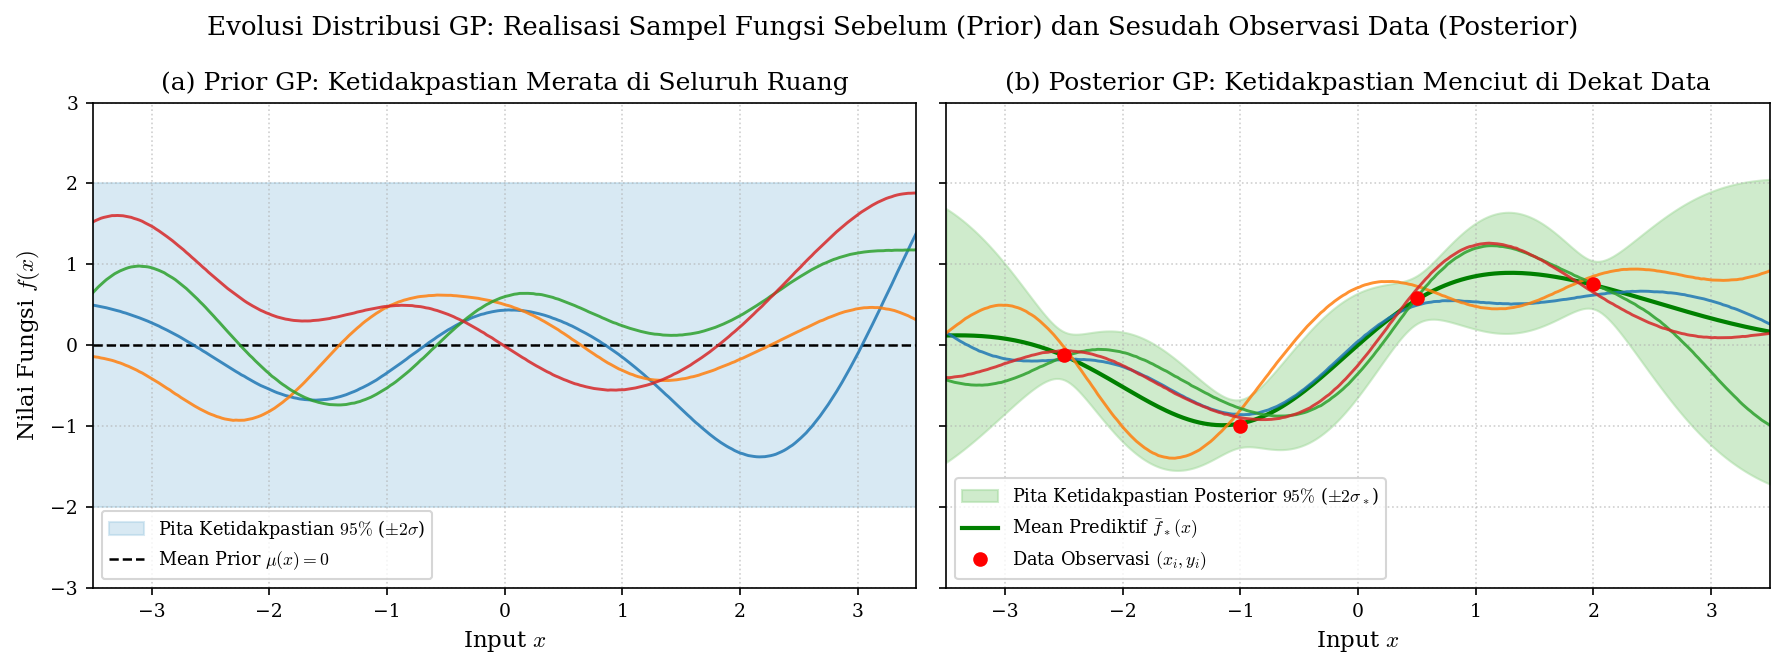

In [7]:
# Visualisasi Sampling Prior vs Posterior (Gambar 5)
x_test = np.linspace(-3.5, 3.5, 300)

# Parameter model
l = 1.0
sigma_f = 1.0
sigma_n = 0.15

# 1. Prior GP
K_ss = kernel_squared_exponential(x_test, x_test, l=l, sigma_f=sigma_f) + 1e-6 * np.eye(len(x_test))
L_prior = np.linalg.cholesky(K_ss)
np.random.seed(42)
prior_samples = L_prior @ np.random.randn(len(x_test), 4)
prior_std = np.sqrt(np.diag(K_ss))

# 2. Data Observasi Training
X_train = np.array([-2.5, -1.0, 0.5, 2.0])
y_train = np.sin(X_train * 1.2) + np.random.normal(0, sigma_n, size=len(X_train))

# 3. Posterior GP Conditioning
K_train = kernel_squared_exponential(X_train, X_train, l=l, sigma_f=sigma_f) + (sigma_n ** 2) * np.eye(len(X_train))
K_s = kernel_squared_exponential(X_train, x_test, l=l, sigma_f=sigma_f)

L_train = np.linalg.cholesky(K_train)
alpha = np.linalg.solve(L_train.T, np.linalg.solve(L_train, y_train))

mu_post = K_s.T @ alpha
v = np.linalg.solve(L_train, K_s)
cov_post = K_ss - v.T @ v + 1e-6 * np.eye(len(x_test))

L_post = np.linalg.cholesky(cov_post)
post_samples = mu_post[:, None] + L_post @ np.random.randn(len(x_test), 4)
post_std = np.sqrt(np.diag(cov_post))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# Plot Prior
ax1.fill_between(x_test, -2 * prior_std, 2 * prior_std, color='#9ecae1', alpha=0.4, label=r'Pita Ketidakpastian $95\%$ ($\pm 2\sigma$)')
ax1.plot(x_test, np.zeros_like(x_test), 'k--', lw=1.2, label=r'Mean Prior $\mu(x)=0$')
for s in range(4):
    ax1.plot(x_test, prior_samples[:, s], lw=1.4, alpha=0.85)
ax1.set_title(r'(a) Prior GP: Ketidakpastian Merata di Seluruh Ruang')
ax1.set_xlabel(r'Input $x$')
ax1.set_ylabel(r'Nilai Fungsi $f(x)$')
ax1.set_xlim([-3.5, 3.5])
ax1.set_ylim([-3.0, 3.0])
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=8.5)

# Plot Posterior
ax2.fill_between(x_test, mu_post - 2 * post_std, mu_post + 2 * post_std, color='#a1d99b', alpha=0.5, label=r'Pita Ketidakpastian Posterior $95\%$ ($\pm 2\sigma_*$)')
ax2.plot(x_test, mu_post, 'g-', lw=2.0, label=r'Mean Prediktif $\bar{f}_*(x)$')
for s in range(4):
    ax2.plot(x_test, post_samples[:, s], lw=1.4, alpha=0.85)
ax2.plot(X_train, y_train, 'ro', markersize=6, zorder=5, label=r'Data Observasi $(x_i, y_i)$')
ax2.set_title(r'(b) Posterior GP: Ketidakpastian Menciut di Dekat Data')
ax2.set_xlabel(r'Input $x$')
ax2.set_xlim([-3.5, 3.5])
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower left', fontsize=8.5)

fig.suptitle(r'Evolusi Distribusi GP: Realisasi Sampel Fungsi Sebelum (Prior) dan Sesudah Observasi Data (Posterior)', fontsize=12.5)

# Simpan ke PDF & PNG
fig.savefig(os.path.join(OUTPUT_DIR, 'fig5_prior_vs_posterior_samples.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'fig5_prior_vs_posterior_samples.png'), bbox_inches='tight')
plt.show()
